# Actividad Práctica: Modelo de Regresión

Una empresa quiere entender cómo su inversión publicitaria afecta sus ventas. Cuentan con datos de 200 observaciones.

## Objetivo de la actividad: 
Construir un modelo de regresión lineal simple para predecir ventas usando la inversión en TV.

# Parte 1: Exploración

## 1.2. Lectura de datos:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

df = pd.read_csv('https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv')

## 1.3 Algunas estadísticas basicas:

       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


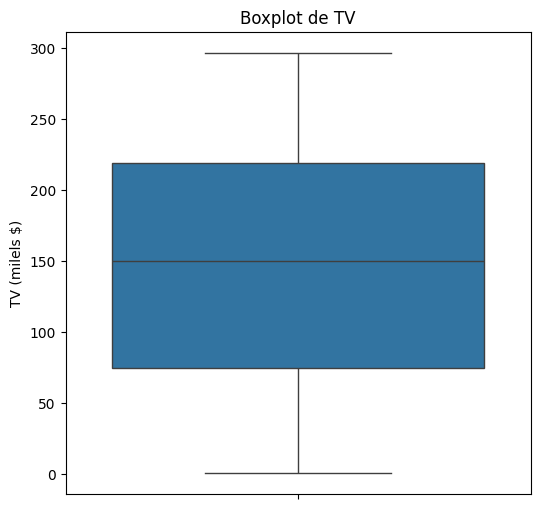

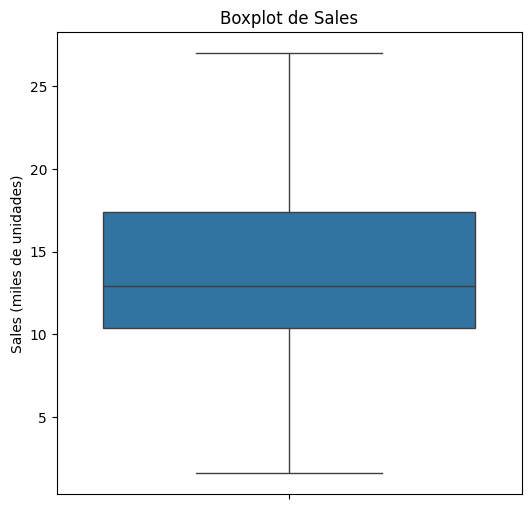

In [24]:
print(df.describe())

plt.figure(figsize=(6, 6))
sns.boxplot(data=df, y='TV')
plt.ylabel('TV (milels $)')
plt.title('Boxplot de TV')
plt.show()

plt.figure(figsize=(6, 6))
sns.boxplot(data=df, y='Sales')
plt.ylabel('Sales (miles de unidades)')
plt.title('Boxplot de Sales')
plt.show()

## 1.4 Correlaciones:

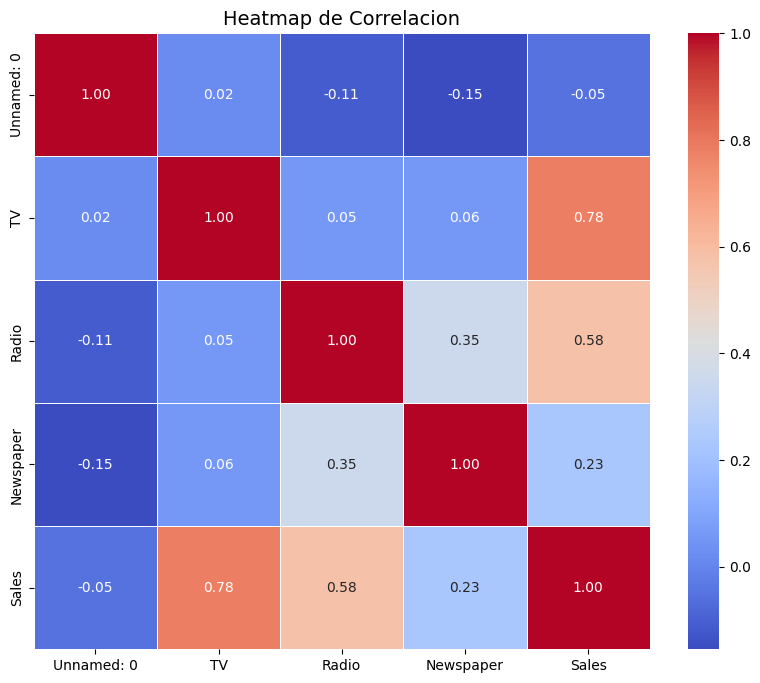

In [25]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths= 0.5)
plt.title('Heatmap de Correlacion', fontsize=14)
plt.show()

## 1.4 Scatter plot:


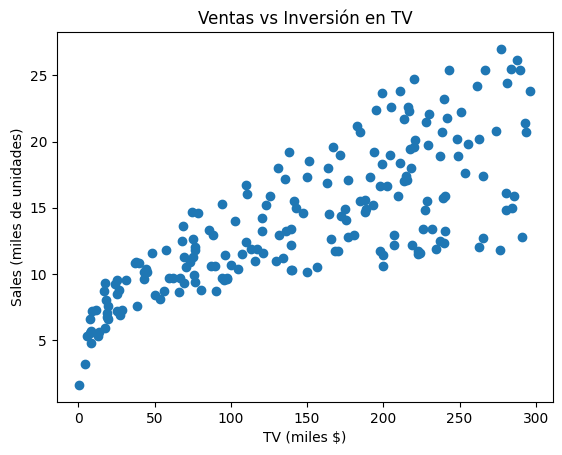

In [26]:
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV (miles $)')
plt.ylabel('Sales (miles de unidades)')
plt.title('Ventas vs Inversión en TV')
plt.show()

Mientras exploras los datos, responde las siguientes preguntas:

- Distribución de variables: ¿Cuál es el rango de TV? ¿Y el de Sales? ¿Hay outliers? Recuerda que los outliers no son únicamente datos fuera de rango...tal vez el fenómeno así es, o tal vez sí fue un error de dedo.

0.7 - 296.4 miles de dolares es el rango de TV

1.6 - 27 miles de unidades vendidas es el rango se Sales

No parece haber outliers dentro dde los datos.

- Correlación TV-Sales: ¿Es positiva o negativa? ¿Qué tan fuerte es?

Es postiva, y su correlación es de 0.78 lo cual es bastante alto

- Patrón en el scatter plot: ¿La relación parece lineal? ¿Hay puntos muy alejados del patrón general?

La relación parece ser lineal, aunque en los extremos más chicos y grandes ambas variables parece haber mayor variabilidad 

# Parte 2: Modelado

El objetivo de esta parte es que entiendas la mecánica de Mínimos Cuadrados Ordinarios (OLS). Calcula los coeficientes manualmente usando las fórmulas cerradas.

## 2A. Implementación desde cero con numpy

In [6]:
# Extraer X y Y
X = df['TV'].values
Y = df['Sales'].values

# Calcular medias
X_mean = np.mean(X)
Y_mean = np.mean(Y)

# Calcular beta_1
numerator = np.sum((X - X_mean) * (Y - Y_mean))
denominator = np.sum((X - X_mean)**2)
beta_1 = numerator / denominator

# Calcular beta_0
beta_0 = Y_mean - beta_1 * X_mean

print(f'beta_0 = {beta_0:.3f}')
print(f'beta_1 = {beta_1:.3f}')

beta_0 = 7.033
beta_1 = 0.048


## 2B. Implementación con scikit-learn 

In [10]:
# Preparar datos (scikit-learn necesita X en formato 2D)
X = df[['TV']]
y = df['Sales']

# Crear y ajustar modelo
model = LinearRegression()
model.fit(X, y)

# Ver coeficientes
print(f'Intercepto: {model.intercept_:.3f}')
print(f'Pendiente: {model.coef_[0]:.3f}')

# Hacer predicciones
y_pred = model.predict(X)

Intercepto: 7.033
Pendiente: 0.048


## 2C. Calcular métricas



In [13]:
# MSE y RMSE
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

# R cuadrado
r2 = r2_score(y, y_pred)

print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

MSE: 10.513
RMSE: 3.242
R²: 0.612


## Parte 3: Visualización 


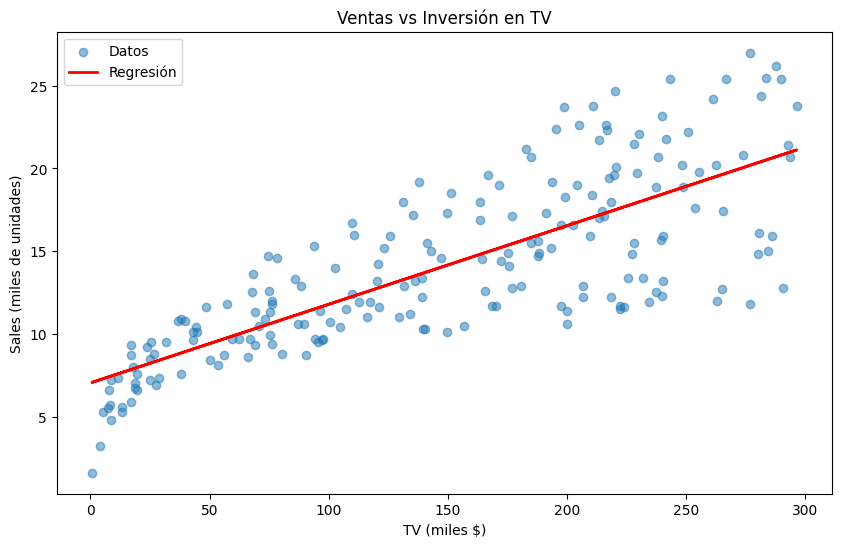

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Datos')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regresión')
plt.xlabel('TV (miles $)')
plt.ylabel('Sales (miles de unidades)')
plt.legend()
plt.title('Ventas vs Inversión en TV')
plt.show()

## 3.2. Gráfico de residuos



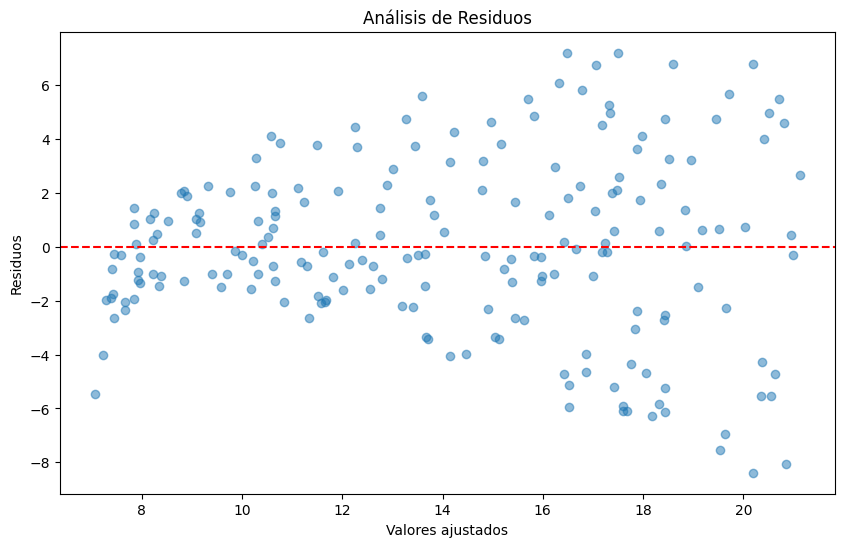

In [15]:
# Calcular residuos
residuals = y - y_pred

# Gráfico de residuos vs predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Análisis de Residuos')
plt.show()

Busca lo siguiente:

- Patrón aleatorio alrededor de cero es buena señal.
- Patrón curvo, problema de linealidad (la relación no es lineal).
- Forma de embudo (dispersión crece o decrece),  heterocedasticidad.

## 3.3. Q-Q Plot



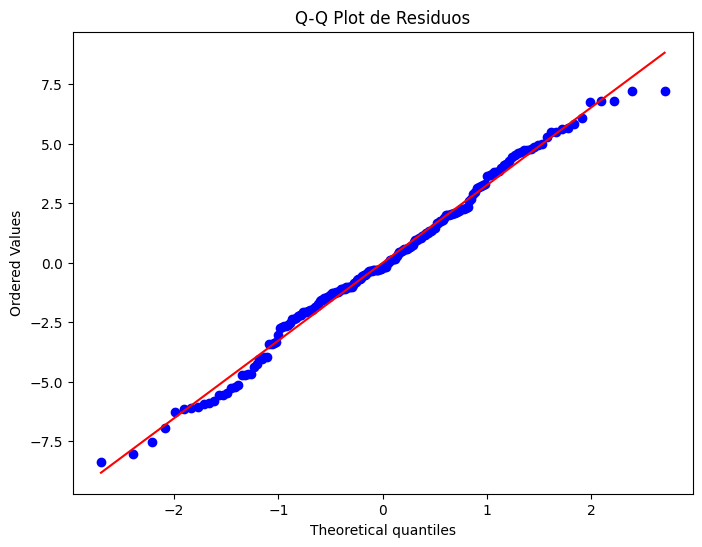

In [17]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

# Parte 4: Interpretación 


- ¿Qué significa β₀ = 7.03?
(Pista: ¿cuántas ventas esperarías con $0 de inversión en TV?)

Es el valor esperado cunado la inversión en TV sea $0

- ¿Qué significa β₁ = 0.048?
(Pista: ¿qué pasa con las ventas si aumentas la inversión en TV en mil dólares?)

Es el cambio esperado en las ventas si aumentas la inversión en TV en miles de dolares

- Si inviertes 100 mil dólares más en TV, ¿cuántas ventas adicionales esperas? 

In [45]:
print(f'{(beta_0 + beta_1 * (100)):3f} miles de ventas')

11.786258 miles de ventas


- R² = 0.61. ¿Es bueno o malo?
(Pista: ¿qué porcentaje de la variabilidad en ventas explica el modelo? ¿Qué porcentaje queda sin explicar?)

Significa que el modelo explica el 61 % de la variabilidad y no explica el 39 %. Dependiendo del medio esto puede ser bueno o malo, pero considerando que es en un ambito de finanzas es muy bueno. 

- ¿Recomendarías invertir más en TV basándote solamente en este análisis?

No, necesitaria un analisis más complejo, ya que correlación no implica causaliddad. Para poder hacer una recomendación necesitarias hacer un experimento donde entendias mejor las variables y el apoyo de un experto para poder interpretar los resultados de la mejor manera.